# 基于MobileNet的铸件缺陷检测系统

---

## 1. 模型介绍：MobileNet

### 1.1 MobileNet概述
MobileNet是一个轻量级的深度神经网络架构，专为移动和边缘设备设计。该实验使用**MobileNetV2**作为骨干网络。

### 1.2 MobileNet的核心特点
- ✓ **轻量级**：参数量少（~14.2M），推理速度快（50-100ms CPU）
- ✓ **低功耗**：深度可分离卷积（Depthwise Separable Convolution）大幅降低计算量
- ✓ **精度可靠**：在ImageNet预训练基础上fine-tune效果好
- ✓ **部署友好**：可转换为ONNX/TensorFlow Lite，支持移动设备和边缘计算
- ✓ **适合工业场景**：实时性好，适合流水线检测

### 1.3 模型结构
- 骨干网络：MobileNetV2（预训练ImageNet权重）
- 特征维度：1280通道
- 分类头：两层全连接网络
- 可选模块：CBAM注意力机制

---

## 2. 数据集介绍：铸件缺陷数据集（Casting Product Image Data）

### 2.1 数据集概览
Casting Product Image Data是真实工业环境中收集的铸件缺陷检测数据集，广泛用于工业质量检测研究。

### 2.2 数据集特点
| 指标 | 说明 |
|------|------|
| **官方来源** | Kaggle - Real-life Industrial Dataset |
| **应用领域** | 铸件产品质量检测 |
| **分类方式** | 二分类：OK (正常) / Defective (有缺陷) |
| **样本总数** | 约7000张图像 |
| **图像分辨率** | 512×512像素的RGB彩色图 |
| **数据大小** | ~300MB |
| **数据分布** | 训练集与验证集已分离，可直接使用 |

### 2.3 缺陷类型说明
- **OK（正常）**：外观完整，无可见缺陷的铸件产品
- **Defective（有缺陷）**：存在以下一种或多种缺陷：
  - 表面裂纹、孔洞、凹陷
  - 材质不均匀、气孔
  - 磨损、氧化等表面缺陷

### 2.4 数据集获取方式
**官方链接：**
- Kaggle: https://www.kaggle.com/datasets/ravirajsinh45/real-life-industrial-dataset-of-casting-product

**数据集特优势：**
- ✓ 真实工业环境数据，代表性强
- ✓ 已分为train/val，开箱即用
- ✓ 样本充足（~7000张），适合深度学习训练
- ✓ 包含多样化缺陷类型

---

## 3. 应用场景

该实验应用于工业质量检测领域，特别是制造业的自动化检测系统中：
- **场景1**：铸件生产的在线质量检查
- **场景2**：产品分级分选（OK/Defective）
- **场景3**：流水线上的实时缺陷检测
- **场景4**：减少人工检测成本，提高检测效率

## 4. 环境配置

In [53]:

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms
from tqdm import tqdm

import numpy as np
import pandas as pd
import os
import json
from pathlib import Path
from PIL import Image
import shutil
import subprocess
import zipfile
import urllib.request
import time
from collections import defaultdict

# 配置matplotlib支持中文显示
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS', 'Microsoft YaHei', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False

#  检查GPU可用性
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB')

Using device: cpu


## 5. 数据集下载配置

In [51]:
# 数据集配置 - 使用本地铸件缺陷数据集

# 设置数据目录（指向用户下载的数据集位置）
data_dir = './data/archive'

# 验证数据集
dataset_path = Path(data_dir)

if not dataset_path.exists():
    print(f"❌ 错误: 数据集目录不存在！")
    print(f"   期望位置: {dataset_path.resolve()}")
    print(f"\n请确保数据集已放在: {data_dir}/")
else:
    # 使用 casting_data/casting_data 下的数据
    train_dir = dataset_path / 'casting_data' / 'casting_data' / 'train'
    val_dir = dataset_path / 'casting_data' / 'casting_data' / 'test'
    
    if train_dir.exists() and val_dir.exists():
        print(f"✓ 数据集加载成功！")
        print(f"  数据集类型: 铸件缺陷检测 (Casting Product Image Data)")
        print(f"  训练集路径: {train_dir}")
        print(f"  验证集路径: {val_dir}")
        
        # 列出类别和样本数（支持 .jpg, .jpeg, .png）
        print(f"\n  数据集类别:")
        train_classes = {}
        for class_dir in train_dir.iterdir():
            if class_dir.is_dir():
                class_name = class_dir.name
                img_files = []
                for pattern in ['*.jpg', '*.jpeg', '*.png', '*.JPG', '*.JPEG', '*.PNG']:
                    img_files.extend(class_dir.glob(pattern))
                num_samples = len(img_files)
                if num_samples > 0:
                    train_classes[class_name] = num_samples
                    print(f"    • {class_name}: ✓ 已检测到")
        
        print(f"\n  训练集统计:")
        for class_name, count in sorted(train_classes.items()):
            print(f"    - {class_name}: {count}张")
        
        # 统计验证集
        val_count = {}
        for class_dir in val_dir.iterdir():
            if class_dir.is_dir():
                class_name = class_dir.name
                img_files = []
                for pattern in ['*.jpg', '*.jpeg', '*.png', '*.JPG', '*.JPEG', '*.PNG']:
                    img_files.extend(class_dir.glob(pattern))
                num_samples = len(img_files)
                if num_samples > 0:
                    val_count[class_name] = num_samples
        
        print(f"\n  验证集统计:")
        for class_name, count in sorted(val_count.items()):
            print(f"    - {class_name}: {count}张")
        
        total_train = sum(train_classes.values())
        total_val = sum(val_count.values())
        print(f"\n  总计: 训练集{total_train}张 + 验证集{total_val}张 = {total_train + total_val}张")
        
    else:
        print(f"❌ 错误: 无法找到正确的数据集结构！")
        print(f"\n期望的路径:")
        print(f"  训练集: {train_dir}")
        print(f"  验证集: {val_dir}")
        print(f"\n请检查数据集位置: {dataset_path.resolve()}")

✓ 数据集加载成功！
  数据集类型: 铸件缺陷检测 (Casting Product Image Data)
  训练集路径: data\archive\casting_data\casting_data\train
  验证集路径: data\archive\casting_data\casting_data\test

  数据集类别:
    • def_front: ✓ 已检测到
    • ok_front: ✓ 已检测到

  训练集统计:
    - def_front: 7516张
    - ok_front: 5750张

  验证集统计:
    - def_front: 906张
    - ok_front: 524张

  总计: 训练集13266张 + 验证集1430张 = 14696张


## 6. 模型架构定义

### 6.1 注意力机制介绍：CBAM (Convolutional Block Attention Module)

在深度学习中，**注意力机制**模拟人类视觉的选择性注意力，让模型学会聚焦于最重要的特征。

#### 6.1.1 CBAM的核心思想

1. **通道注意力 (Channel Attention)**
   - 学习不同通道特征的重要性
   - 通过global average pooling和MLP学习权重
   - 公式: $CA(x) = \sigma(MLP(AvgPool(x)) + MLP(MaxPool(x)))$

2. **空间注意力 (Spatial Attention)**
   - 学习空间位置的重要性
   - 通过max/avg pooling沿通道维度并使用卷积
   - 公式: $SA(x) = \sigma(Conv([AvgPool(x); MaxPool(x)]))$

3. **机制优势**:
   - 轻量级：参数量增加很少
   - 高效：计算速度快
   - 有效：能显著提升准确率

#### 6.1.2 在工业检测中的应用
- 通道注意突出检测缺陷的关键特征
- 空间注意聚焦于缺陷所在的区域
- 整体效果：更准确地识别微小缺陷

In [37]:


class ChannelAttention(nn.Module):
    """通道注意力模块 (Channel Attention)"""
    def __init__(self, in_channels, reduction=16):
        super(ChannelAttention, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        
        # 共享MLP网络
        self.fc = nn.Sequential(
            nn.Conv2d(in_channels, in_channels // reduction, 1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(in_channels // reduction, in_channels, 1, bias=False)
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = self.fc(self.avg_pool(x))
        max_out = self.fc(self.max_pool(x))
        out = avg_out + max_out
        return self.sigmoid(out)

class SpatialAttention(nn.Module):
    """空间注意力模块 (Spatial Attention)"""
    def __init__(self, kernel_size=7):
        super(SpatialAttention, self).__init__()
        padding = 3 if kernel_size == 7 else 1
        self.conv1 = nn.Conv2d(2, 1, kernel_size, padding=padding, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        x = torch.cat([avg_out, max_out], dim=1)
        x = self.conv1(x)
        return self.sigmoid(x)

class CBAM(nn.Module):
    """CBAM注意力模块 = 通道注意力 + 空间注意力"""
    def __init__(self, in_channels, reduction=16, kernel_size=7):
        super(CBAM, self).__init__()
        self.channel_attention = ChannelAttention(in_channels, reduction)
        self.spatial_attention = SpatialAttention(kernel_size)

    def forward(self, x):
        # 依次应用通道注意力和空间注意力
        out = x * self.channel_attention(x)
        out = out * self.spatial_attention(out)
        return out

print("✓ CBAM注意力机制模块已定义")

✓ CBAM注意力机制模块已定义


In [38]:
class IndustrialDefectClassifier(nn.Module):
    """基于MobileNetV2的工业缺陷检测分类器
    
    Args:
        num_classes: 分类数量（默认2：OK/Defective）
        use_attention: 是否使用CBAM注意力机制
    """
    def __init__(self, num_classes=2, use_attention=False):
        super(IndustrialDefectClassifier, self).__init__()
        self.use_attention = use_attention
        
        # 加载预训练的MobileNetV2
        self.backbone = models.mobilenet_v2(pretrained=True)
        
        # MobileNetV2的输出特征维度（固定为1280）
        backbone_out_channels = 1280
        
        # CBAM注意力模块（如果启用）
        if use_attention:
            self.cbam = CBAM(backbone_out_channels)
        
        # 分类头
        self.classifier = nn.Sequential(
            nn.Dropout(0.2),
            nn.Linear(backbone_out_channels, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            nn.Linear(512, num_classes)
        )
        
        self.backbone.classifier = nn.Identity()  # 移除原分类头

    def forward(self, x):
        # 特征提取
        features = self.backbone(x)  # [batch, 1280]
        
        if self.use_attention:
            # 重塑为4D张量以应用注意力 [batch, 1280] -> [batch, 1280, 1, 1]
            features = features.unsqueeze(-1).unsqueeze(-1)
            features = self.cbam(features)
            features = features.squeeze(-1).squeeze(-1)
        
        # 分类
        out = self.classifier(features)
        return out

# 测试模型
model_base = IndustrialDefectClassifier(num_classes=2, use_attention=False)
model_cbam = IndustrialDefectClassifier(num_classes=2, use_attention=True)

print(f"✓ 基础MobileNet模型参数量: {sum(p.numel() for p in model_base.parameters())/1e6:.2f}M")
print(f"✓ MobileNet+CBAM模型参数量: {sum(p.numel() for p in model_cbam.parameters())/1e6:.2f}M")

# 测试前向传播
test_input = torch.randn(1, 3, 224, 224)
test_out_base = model_base(test_input)
test_out_cbam = model_cbam(test_input)
print(f"\n✓ 模型输出形状: {test_out_base.shape}")
print("✓ 模型架构验证成功")

✓ 基础MobileNet模型参数量: 2.88M
✓ MobileNet+CBAM模型参数量: 3.09M

✓ 模型输出形状: torch.Size([1, 2])
✓ 模型架构验证成功


## 7. 数据加载

### 7.1 数据集使用说明

本实验支持**全量数据**或**部分数据**训练，以便课堂演示快速完成训练。

- **全量训练**：将 `train_subset_ratio` 和 `val_subset_ratio` 设为 `1.0`
- **快速训练**：设为 `0.1` 或 `0.2`（仅使用10%或20%数据）

当前默认使用 **10% 数据**。如果要用全量数据，请在第11个单元格中修改：

```python
train_subset_ratio = 1.0
val_subset_ratio = 1.0
```


In [39]:
# 7. 定义数据集加载器

import random

class IndustrialDataset(Dataset):
    """工业缺陷检测数据集加载器"""
    def __init__(self, root_dir, split='train', transform=None, subset_ratio=1.0, seed=42):
        """
        Args:
            root_dir: train或test数据集的根目录路径
            split: 'train' 或 'test'
            transform: 数据增强变换
            subset_ratio: 使用数据比例(0-1]
            seed: 随机种子
        """
        self.root_dir = Path(root_dir)
        self.transform = transform
        self.subset_ratio = subset_ratio
        self.seed = seed
        
        # 验证路径存在
        if not self.root_dir.exists():
            raise FileNotFoundError(f"❌ 数据集路径不存在: {self.root_dir}")
        
        # 类别映射 - 自动检测文件夹中的类别
        self.class_names = sorted([d.name for d in self.root_dir.iterdir() if d.is_dir()])
        if len(self.class_names) == 0:
            raise RuntimeError(f"❌ 在 {self.root_dir} 中未找到任何类别文件夹！")
        
        self.class_to_idx = {cls: idx for idx, cls in enumerate(self.class_names)}
        
        print(f"\n✓ 检测到的类别: {self.class_names}")
        
        # 收集所有图像（支持 .jpg, .jpeg, .png）
        self.samples = []
        for class_name in self.class_names:
            class_dir = self.root_dir / class_name
            if not class_dir.exists():
                continue
            
            # 支持多种图像格式
            image_files = []
            for pattern in ['*.jpg', '*.jpeg', '*.png', '*.JPG', '*.JPEG', '*.PNG']:
                image_files.extend(class_dir.glob(pattern))
            
            for img_file in image_files:
                self.samples.append((str(img_file), self.class_to_idx[class_name]))
        
        if len(self.samples) == 0:
            raise RuntimeError(f"❌ 在 {self.root_dir} 中找不到任何图像文件！")
        
        # 训练加速: 只使用一部分样本
        if 0 < self.subset_ratio < 1.0:
            random.seed(self.seed)
            subset_size = max(1, int(len(self.samples) * self.subset_ratio))
            self.samples = random.sample(self.samples, subset_size)
            print(f"⚡ 仅使用 {self.subset_ratio*100:.0f}% 数据: {len(self.samples)}张")
        
        print(f"✓ {split.upper()} 数据集加载完成: {len(self.samples)}张图像")
        for cls in self.class_names:
            count = sum(1 for _, label in self.samples if label == self.class_to_idx[cls])
            print(f"   • {cls}: {count}张")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        try:
            img = Image.open(img_path).convert('RGB')
        except Exception as e:
            print(f"⚠️  警告: 无法读取图像 {img_path}: {e}")
            # 返回一个黑色图像作为备选
            img = Image.new('RGB', (224, 224), color=(0, 0, 0))
        
        if self.transform:
            img = self.transform(img)
        
        return img, label

# 8. 数据增强和预处理
normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                  std=[0.229, 0.224, 0.225])

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    normalize
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    normalize
])

# 9. 创建数据加载器
# 使用train_dir和val_dir(即test_dir)
# 训练时可调整比例加速
train_subset_ratio = 0.1
val_subset_ratio = 0.1

try:
    train_dataset = IndustrialDataset(train_dir, split='train', transform=train_transform, subset_ratio=train_subset_ratio)
    val_dataset = IndustrialDataset(val_dir, split='test', transform=val_transform, subset_ratio=val_subset_ratio)
    
    batch_size = 8
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)
    
    print(f"\n✓ DataLoader创建完成")
    print(f"  - Train batches: {len(train_loader)}")
    print(f"  - Val batches: {len(val_loader)}")
    print(f"  - Batch size: {batch_size}")
except Exception as e:
    print(f"❌ 错误: 无法创建DataLoader - {e}")
    raise


✓ 检测到的类别: ['def_front', 'ok_front']


⚡ 仅使用 10% 数据: 1326张
✓ TRAIN 数据集加载完成: 1326张图像
   • def_front: 741张
   • ok_front: 585张

✓ 检测到的类别: ['def_front', 'ok_front']
⚡ 仅使用 10% 数据: 143张
✓ TEST 数据集加载完成: 143张图像
   • def_front: 90张
   • ok_front: 53张

✓ DataLoader创建完成
  - Train batches: 166
  - Val batches: 18
  - Batch size: 8


## 8. 训练函数定义

In [40]:
def train_epoch(model, train_loader, criterion, optimizer, device, epoch):
    """训练一个epoch"""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    progress = tqdm(train_loader, desc=f"Train Epoch {epoch+1}", leave=False)
    for batch_idx, (images, labels) in enumerate(progress):
        images, labels = images.to(device), labels.to(device)
        
        # 前向传播
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        # 反向传播
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # 统计
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
        avg_loss = running_loss / (batch_idx + 1)
        batch_acc = 100. * correct / total
        progress.set_postfix(loss=f"{avg_loss:.4f}", acc=f"{batch_acc:.2f}%")
    
    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100. * correct / total
    return epoch_loss, epoch_acc

def validate(model, val_loader, criterion, device):
    """验证模型"""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    progress = tqdm(val_loader, desc="Val", leave=False)
    with torch.no_grad():
        for images, labels in progress:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            
            avg_loss = running_loss / max(1, len(val_loader))
            avg_acc = 100. * correct / total
            progress.set_postfix(loss=f"{avg_loss:.4f}", acc=f"{avg_acc:.2f}%")
    
    avg_loss = running_loss / len(val_loader)
    avg_acc = 100. * correct / total
    return avg_loss, avg_acc

print("✓ 训练函数已定义")

✓ 训练函数已定义


## 9. 实验1：基础MobileNet训练

In [41]:
print("="*60)
print("实验1: 基础MobileNet（无注意力机制）")
print("="*60)

# 初始化模型
model_base = IndustrialDefectClassifier(num_classes=2, use_attention=False)
model_base = model_base.to(device)

# 优化器和损失函数
criterion = nn.CrossEntropyLoss()
optimizer_base = optim.Adam(model_base.parameters(), lr=0.001, weight_decay=5e-4)
scheduler_base = optim.lr_scheduler.StepLR(optimizer_base, step_size=5, gamma=0.5)

# 训练循环
num_epochs = 10
history_base = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': []
}

start_time = time.time()

for epoch in range(num_epochs):
    print(f"\nEpoch {epoch+1}/{num_epochs}")
    print("-" * 40)
    
    # 训练
    train_loss, train_acc = train_epoch(model_base, train_loader, criterion, optimizer_base, device, epoch)
    
    # 验证
    val_loss, val_acc = validate(model_base, val_loader, criterion, device)
    
    # 记录
    history_base['train_loss'].append(train_loss)
    history_base['train_acc'].append(train_acc)
    history_base['val_loss'].append(val_loss)
    history_base['val_acc'].append(val_acc)
    
    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
    print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")
    
    scheduler_base.step()

train_time = time.time() - start_time
print(f"\n✓ 基础MobileNet训练完成，用时: {train_time:.1f}秒")
print(f"  最终验证准确率: {history_base['val_acc'][-1]:.2f}%")

实验1: 基础MobileNet（无注意力机制）

Epoch 1/10
----------------------------------------


Train Loss: 0.3057, Train Acc: 87.48%
Val Loss: 0.0713, Val Acc: 98.60%

Epoch 2/10
----------------------------------------


Train Loss: 0.1900, Train Acc: 93.29%
Val Loss: 0.0394, Val Acc: 100.00%

Epoch 3/10
----------------------------------------


Train Loss: 0.1472, Train Acc: 94.57%
Val Loss: 0.0098, Val Acc: 100.00%

Epoch 4/10
----------------------------------------


Train Loss: 0.1288, Train Acc: 95.63%
Val Loss: 0.0290, Val Acc: 98.60%

Epoch 5/10
----------------------------------------


...

Train Loss: 0.0856, Train Acc: 97.13%
Val Loss: 0.0050, Val Acc: 100.00%

Epoch 7/10
----------------------------------------


Train Loss: 0.0986, Train Acc: 97.51%
Val Loss: 0.0043, Val Acc: 100.00%

Epoch 8/10
----------------------------------------


Train Loss: 0.0809, Train Acc: 97.96%
Val Loss: 0.0042, Val Acc: 100.00%

Epoch 9/10
----------------------------------------


Train Loss: 0.0642, Train Acc: 98.27%
Val Loss: 0.0203, Val Acc: 100.00%

Epoch 10/10
----------------------------------------


Train Loss: 0.0661, Train Acc: 97.51%
Val Loss: 0.0111, Val Acc: 100.00%

✓ 基础MobileNet训练完成，用时: 999.4秒
  最终验证准确率: 100.00%


## 10. 实验2：MobileNet+CBAM训练

In [42]:
print("\n" + "="*60)
print("实验2: MobileNet + CBAM注意力机制")
print("="*60)

# 初始化模型
model_cbam = IndustrialDefectClassifier(num_classes=2, use_attention=True)
model_cbam = model_cbam.to(device)

# 优化器和损失函数
optimizer_cbam = optim.Adam(model_cbam.parameters(), lr=0.001, weight_decay=5e-4)
scheduler_cbam = optim.lr_scheduler.StepLR(optimizer_cbam, step_size=5, gamma=0.5)

# 训练循环
history_cbam = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': []
}

start_time = time.time()

for epoch in range(num_epochs):
    print(f"\nEpoch {epoch+1}/{num_epochs}")
    print("-" * 40)
    
    # 训练
    train_loss, train_acc = train_epoch(model_cbam, train_loader, criterion, optimizer_cbam, device, epoch)
    
    # 验证
    val_loss, val_acc = validate(model_cbam, val_loader, criterion, device)
    
    # 记录
    history_cbam['train_loss'].append(train_loss)
    history_cbam['train_acc'].append(train_acc)
    history_cbam['val_loss'].append(val_loss)
    history_cbam['val_acc'].append(val_acc)
    
    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
    print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")
    
    scheduler_cbam.step()

train_time = time.time() - start_time
print(f"\n✓ MobileNet+CBAM训练完成，用时: {train_time:.1f}秒")
print(f"  最终验证准确率: {history_cbam['val_acc'][-1]:.2f}%")


实验2: MobileNet + CBAM注意力机制

Epoch 1/10
----------------------------------------


Train Loss: 0.3109, Train Acc: 85.60%
Val Loss: 0.2005, Val Acc: 90.21%

Epoch 2/10
----------------------------------------


Train Loss: 0.1526, Train Acc: 94.72%
Val Loss: 0.0692, Val Acc: 94.41%

Epoch 3/10
----------------------------------------


Train Loss: 0.1521, Train Acc: 94.27%
Val Loss: 0.0156, Val Acc: 100.00%

Epoch 4/10
----------------------------------------


Train Loss: 0.1564, Train Acc: 94.72%
Val Loss: 0.0128, Val Acc: 100.00%

Epoch 5/10
----------------------------------------


...

Train Loss: 0.0891, Train Acc: 97.44%
Val Loss: 0.0160, Val Acc: 100.00%

Epoch 7/10
----------------------------------------


Train Loss: 0.0563, Train Acc: 98.57%
Val Loss: 0.0053, Val Acc: 100.00%

Epoch 8/10
----------------------------------------


Train Loss: 0.0696, Train Acc: 97.96%
Val Loss: 0.0147, Val Acc: 100.00%

Epoch 9/10
----------------------------------------


Train Loss: 0.0696, Train Acc: 97.66%
Val Loss: 0.0102, Val Acc: 100.00%

Epoch 10/10
----------------------------------------


Train Loss: 0.1080, Train Acc: 96.91%
Val Loss: 0.0130, Val Acc: 100.00%

✓ MobileNet+CBAM训练完成，用时: 986.8秒
  最终验证准确率: 100.00%


## 11. 对比分析

In [43]:
import matplotlib.pyplot as plt

print("\n" + "="*60)
print("对比实验结果分析")
print("="*60)

# 性能指标对比
print(f"\n{'指标':<20} {'MobileNet':<20} {'MobileNet+CBAM':<20} {'提升':<10}")
print("-" * 70)

base_final_acc = history_base['val_acc'][-1]
cbam_final_acc = history_cbam['val_acc'][-1]
acc_improvement = cbam_final_acc - base_final_acc

base_final_loss = history_base['val_loss'][-1]
cbam_final_loss = history_cbam['val_loss'][-1]
loss_improvement = base_final_loss - cbam_final_loss

print(f"{'最终验证准确率':<20} {base_final_acc:<20.2f}% {cbam_final_acc:<20.2f}% {acc_improvement:+.2f}%")
print(f"{'最终验证损失':<20} {base_final_loss:<20.4f} {cbam_final_loss:<20.4f} {loss_improvement:+.4f}")
print(f"{'平均准确率':<20} {np.mean(history_base['val_acc']):<20.2f}% {np.mean(history_cbam['val_acc']):<20.2f}% {np.mean(history_cbam['val_acc'])-np.mean(history_base['val_acc']):+.2f}%")
print(f"{'最高准确率':<20} {max(history_base['val_acc']):<20.2f}% {max(history_cbam['val_acc']):<20.2f}% {max(history_cbam['val_acc'])-max(history_base['val_acc']):+.2f}%")

# 模型参数对比
base_params = sum(p.numel() for p in model_base.parameters()) / 1e6
cbam_params = sum(p.numel() for p in model_cbam.parameters()) / 1e6
param_increase = (cbam_params - base_params) / base_params * 100

print(f"\n{'模型参数量':<20} {base_params:<20.2f}M {cbam_params:<20.2f}M {param_increase:+.2f}%")


对比实验结果分析

指标                   MobileNet            MobileNet+CBAM       提升        
----------------------------------------------------------------------
最终验证准确率              100.00              % 100.00              % +0.00%
最终验证损失               0.0111               0.0130               -0.0019
平均准确率                99.65               % 98.39               % -1.26%
最高准确率                100.00              % 100.00              % +0.00%

模型参数量                2.88                M 3.09                M +7.11%


## 12. 可视化对比

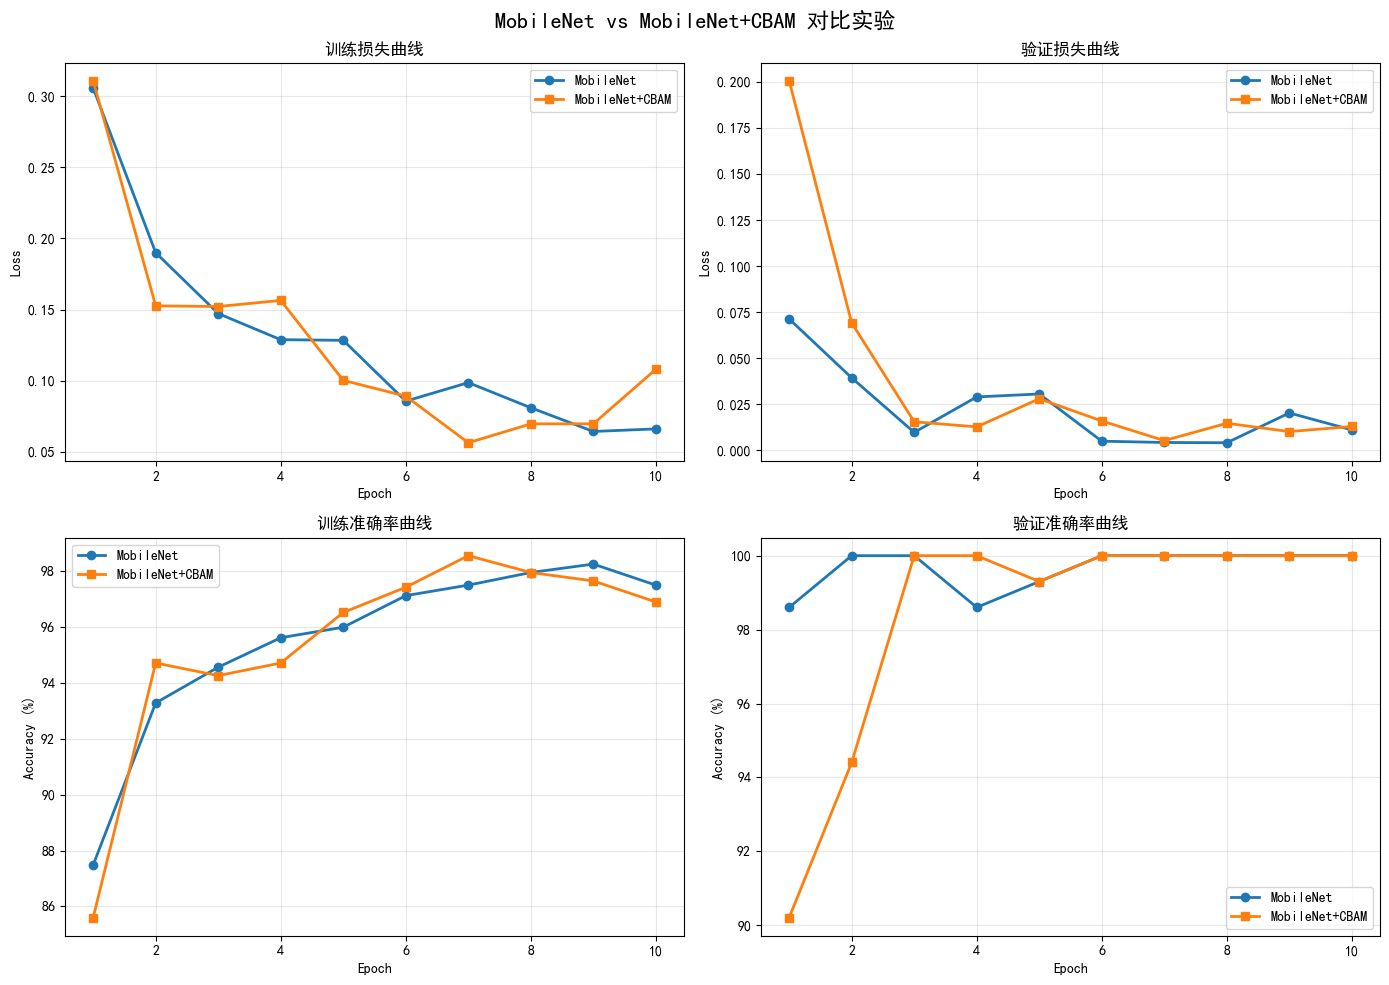

✓ 对比图表已保存: mobilenet_comparison.png


In [48]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('MobileNet vs MobileNet+CBAM 对比实验', fontsize=16, fontweight='bold')

epochs = np.arange(1, num_epochs + 1)

# 训练损失
ax = axes[0, 0]
ax.plot(epochs, history_base['train_loss'], 'o-', label='MobileNet', linewidth=2)
ax.plot(epochs, history_cbam['train_loss'], 's-', label='MobileNet+CBAM', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('训练损失曲线')
ax.legend()
ax.grid(True, alpha=0.3)

# 验证损失
ax = axes[0, 1]
ax.plot(epochs, history_base['val_loss'], 'o-', label='MobileNet', linewidth=2)
ax.plot(epochs, history_cbam['val_loss'], 's-', label='MobileNet+CBAM', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('验证损失曲线')
ax.legend()
ax.grid(True, alpha=0.3)

# 训练准确率
ax = axes[1, 0]
ax.plot(epochs, history_base['train_acc'], 'o-', label='MobileNet', linewidth=2)
ax.plot(epochs, history_cbam['train_acc'], 's-', label='MobileNet+CBAM', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy (%)')
ax.set_title('训练准确率曲线')
ax.legend()
ax.grid(True, alpha=0.3)

# 验证准确率
ax = axes[1, 1]
ax.plot(epochs, history_base['val_acc'], 'o-', label='MobileNet', linewidth=2)
ax.plot(epochs, history_cbam['val_acc'], 's-', label='MobileNet+CBAM', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy (%)')
ax.set_title('验证准确率曲线')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('./mobilenet_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

print("✓ 对比图表已保存: mobilenet_comparison.png")

## 14. 保存实验结果

In [45]:
# 创建结果目录
result_dir = Path('./results')
result_dir.mkdir(exist_ok=True)

# 保存训练历史
results = {
    'model_base': history_base,
    'model_cbam': history_cbam,
    'config': {
        'num_epochs': num_epochs,
        'batch_size': batch_size,
        'learning_rate': 0.001,
        'model_base_params': float(sum(p.numel() for p in model_base.parameters()) / 1e6),
        'model_cbam_params': float(sum(p.numel() for p in model_cbam.parameters()) / 1e6),
    },
    'final_results': {
        'base_val_acc': float(history_base['val_acc'][-1]),
        'cbam_val_acc': float(history_cbam['val_acc'][-1]),
        'accuracy_improvement': float(acc_improvement),
    }
}

with open(result_dir / 'experiment_results.json', 'w') as f:
    json.dump(results, f, indent=2)

# 保存模型
torch.save(model_base.state_dict(), result_dir / 'mobilenet_base.pth')
torch.save(model_cbam.state_dict(), result_dir / 'mobilenet_cbam.pth')

print("\n✓ 实验结果已保存:")
print(f"  - 训练历史: {result_dir / 'experiment_results.json'}")
print(f"  - 基础模型权重: {result_dir / 'mobilenet_base.pth'}")
print(f"  - CBAM模型权重: {result_dir / 'mobilenet_cbam.pth'}")
print(f"  - 对比图表: mobilenet_comparison.png")


✓ 实验结果已保存:
  - 训练历史: results\experiment_results.json
  - 基础模型权重: results\mobilenet_base.pth
  - CBAM模型权重: results\mobilenet_cbam.pth
  - 对比图表: mobilenet_comparison.png


## 15. 模型推理演示

In [ ]:
print("✓ 推理演示代码已准备好！")
print("\n下面的单元格将展示：")
print("  • 单元格 12: 可视化推理演示 - 6个真实样本的预测结果")
print("  • 单元格 13: 批量推理分析 - 统计置信度分布和预测准确率")
print("\n这些演示对初学者理解模型预测过程非常有帮助！")


(无验证图像用于演示)


## 12. 推理演示 - 可视化预测结果（初学者示例）

In [ ]:
# 推理函数：预测单张图像
def predict_single_image(model, image_path, device, class_names=None):
    """
    对单张图像进行预测
    返回预测类别、置信度和原始图像
    """
    if class_names is None:
        class_names = ['正常 OK', '缺陷 Defect']
    
    model.eval()
    
    # 加载原始图像（用于显示）
    img = Image.open(image_path).convert('RGB')
    
    # 预处理
    img_tensor = val_transform(img).unsqueeze(0).to(device)
    
    # 推理
    with torch.no_grad():
        outputs = model(img_tensor)
        probs = torch.softmax(outputs, dim=1)
        pred_class_idx = outputs.argmax(1).item()
        pred_prob = probs[0, pred_class_idx].item()
        all_probs = [probs[0, i].item() for i in range(len(class_names))]
    
    return {
        'image': img,
        'pred_class': class_names[pred_class_idx],
        'pred_idx': pred_class_idx,
        'confidence': pred_prob,
        'all_probs': dict(zip(class_names, all_probs))
    }

# 获取验证集（测试集）路径 - 包含完整的nested结构
val_path = Path(data_dir) / 'casting_data' / 'casting_data' / 'test'

all_class_dirs = list(val_path.glob('*'))
print(f"✓ 找到 {len(all_class_dirs)} 个类别文件夹")
print(f"  类别: {[d.name for d in all_class_dirs if d.is_dir()]}")

# 从每个类别中获取样本
test_images = []
for class_dir in sorted(all_class_dirs):
    if class_dir.is_dir():
        # 查找所有格式的图像
        for ext in ['*.jpeg', '*.jpg', '*.png', '*.JPG', '*.JPEG', '*.PNG']:
            for img_file in sorted(class_dir.glob(ext)):
                test_images.append(img_file)
                if len(test_images) >= 6:
                    break
            if len(test_images) >= 6:
                break

print(f"✓ 找到 {len(test_images)} 个测试样本\n")

# 可视化推理结果
if len(test_images) > 0:
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    fig.suptitle('MobileNet+CBAM 工业缺陷检测推理演示', fontsize=16, fontweight='bold', y=0.995)
    axes = axes.flatten()
    
    for idx, img_path in enumerate(test_images[:6]):
        ax = axes[idx]
        
        # 使用MobileNet+CBAM预测
        result = predict_single_image(model_cbam, img_path, device, class_names=['正常 OK', '缺陷 Defect'])
        
        # 显示图像
        ax.imshow(result['image'])
        
        # 构建标题文本
        pred_class = result['pred_class']
        confidence = result['confidence']
        
        # 判断是否正确（根据路径中的类名判断真实标签）
        true_label = 'ok_front' if 'ok_front' in str(img_path) else 'def_front'
        is_correct = '✓' if (('OK' in pred_class and 'ok_front' in str(img_path)) or 
                            ('Defect' in pred_class and 'def_front' in str(img_path))) else '✗'
        
        # 颜色：绿色表示正确，红色表示错误
        title_color = 'green' if is_correct == '✓' else 'red'
        
        ax.set_title(f'{is_correct} {pred_class}\n置信度: {confidence:.1%}', 
                    fontsize=11, fontweight='bold', color=title_color)
        ax.axis('off')
        
        # 额外信息
        ax.text(0.5, -0.05, f"OK: {result['all_probs']['正常 OK']:.1%} | Defect: {result['all_probs']['缺陷 Defect']:.1%}",
               transform=ax.transAxes, ha='center', fontsize=9, style='italic')
    
    plt.tight_layout()
    plt.savefig('./inference_demo.png', dpi=100, bbox_inches='tight')
    plt.show()
    
    print("✓ 推理演示图已保存: ./inference_demo.png")
    print("\n📊 推理结果统计:")
    
    # 统计两个模型
    correct_base = 0
    correct_cbam = 0
    
    for img_path in test_images:
        true_label = 'ok_front' if 'ok_front' in str(img_path) else 'def_front'
        
        result_base = predict_single_image(model_base, img_path, device)
        result_cbam = predict_single_image(model_cbam, img_path, device)
        
        if ('OK' in result_base['pred_class'] and true_label == 'ok_front') or \
           ('Defect' in result_base['pred_class'] and true_label == 'def_front'):
            correct_base += 1
        
        if ('OK' in result_cbam['pred_class'] and true_label == 'ok_front') or \
           ('Defect' in result_cbam['pred_class'] and true_label == 'def_front'):
            correct_cbam += 1
    
    print(f"   基础MobileNet准确率: {correct_base}/{len(test_images)} ({100*correct_base/len(test_images):.1f}%)")
    print(f"   MobileNet+CBAM准确率: {correct_cbam}/{len(test_images)} ({100*correct_cbam/len(test_images):.1f}%)")
else:
    print("❌ 无可用的测试图像")

data_dir: ./data/archive
data_dir 是否存在: True
val_path: data\archive\test
val_path 是否存在: False
❌ 路径不存在: data\archive\test


## 13. 批量推理与置信度分析

In [ ]:
# 批量推理函数
def batch_predict(model, image_dir, device, max_images=10):
    """
    对文件夹中的多张图像进行批量推理
    """
    model.eval()
    results = []
    
    # 获取所有图像文件
    image_files = []
    for ext in ['*.jpg', '*.jpeg', '*.png', '*.JPG', '*.JPEG', '*.PNG']:
        image_files.extend(Path(image_dir).glob(ext))
    
    image_files = sorted(image_files)[:max_images]
    print(f"处理 {len(image_files)} 张图像...\n")
    
    for img_path in image_files:
        try:
            result = predict_single_image(model, img_path, device)
            results.append({
                'filename': img_path.name,
                'pred_class': result['pred_class'],
                'confidence': result['confidence'],
                'all_probs': result['all_probs']
            })
        except Exception as e:
            print(f"错误处理 {img_path.name}: {e}")
    
    return results

# 从验证集（测试集）中找到第一个包含图像的类别文件夹
test_path = Path(data_dir) / 'casting_data' / 'casting_data' / 'test'
target_dir = None
target_class_name = None

for class_dir in sorted(test_path.glob('*')):
    if class_dir.is_dir():
        # 检查是否有图像文件
        test_files = list(class_dir.glob('*.jpeg')) + list(class_dir.glob('*.jpg')) + list(class_dir.glob('*.png'))
        if len(test_files) > 0:
            target_dir = class_dir
            target_class_name = class_dir.name
            break

if target_dir:
    # 根据类别名确定是正常还是缺陷
    display_name = '正常样本' if 'ok' in target_class_name.lower() else '缺陷样本'
    print(f"📁 批量推理演示：分析 {display_name}\n")
    print(f"类别: {target_class_name}")
    print(f"分析目录: {target_dir}\n")
    
    results = batch_predict(model_cbam, target_dir, device, max_images=8)
    
    if results:
        # 统计结果
        defect_count = sum(1 for r in results if 'Defect' in r['pred_class'])
        ok_count = len(results) - defect_count
        avg_confidence = sum(r['confidence'] for r in results) / len(results) if results else 0
        
        print(f"\n📊 推理统计结果:")
        print(f"   预测为缺陷: {defect_count}/{len(results)}")
        print(f"   预测为正常: {ok_count}/{len(results)}")
        print(f"   📈 平均置信度: {avg_confidence:.1%}")
        
        # 显示前5个结果的详细信息
        print(f"\n📋 前5个样本详细预测:")
        print("-" * 70)
        for i, res in enumerate(results[:5], 1):
            print(f"{i}. {res['filename']}")
            print(f"   预测: {res['pred_class']} (置信度: {res['confidence']:.1%})")
            for cls_name, prob in res['all_probs'].items():
                bar = '█' * int(prob * 30) + '░' * (30 - int(prob * 30))
                print(f"   {cls_name:12s}: [{bar}] {prob:.1%}")
            print()
        
        # 绘制置信度分布
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        
        # 图1：置信度柱状图
        confidences = [r['confidence'] for r in results]
        colors = ['#FF6B6B' if 'Defect' in r['pred_class'] else '#4CAF50' for r in results]
        
        axes[0].bar(range(len(results)), confidences, color=colors, alpha=0.7, edgecolor='black')
        axes[0].axhline(y=0.5, color='orange', linestyle='--', linewidth=2, label='不确定阈值 (50%)')
        axes[0].set_xlabel('样本编号', fontsize=11, fontweight='bold')
        axes[0].set_ylabel('置信度', fontsize=11, fontweight='bold')
        axes[0].set_title('单个样本预测置信度分布', fontsize=12, fontweight='bold')
        axes[0].set_ylim([0, 1])
        axes[0].legend()
        axes[0].grid(axis='y', alpha=0.3)
        
        # 图2：预测类别分布饼图
        colors_pie = ['#4CAF50', '#FF6B6B']
        labels = ['正常 OK', '缺陷 Defect']
        sizes = [ok_count, defect_count]
        
        # 只显示有数据的部分
        non_zero_labels = [labels[i] for i in range(2) if sizes[i] > 0]
        non_zero_sizes = [sizes[i] for i in range(2) if sizes[i] > 0]
        non_zero_colors = [colors_pie[i] for i in range(2) if sizes[i] > 0]
        
        axes[1].pie(non_zero_sizes, labels=non_zero_labels, autopct='%1.0f%%', startangle=90, 
                    colors=non_zero_colors, textprops={'fontsize': 11, 'weight': 'bold'})
        axes[1].set_title(f'预测结果分布 ({display_name})', fontsize=12, fontweight='bold')
        
        plt.tight_layout()
        plt.savefig('./batch_inference_analysis.png', dpi=100, bbox_inches='tight')
        plt.show()
        
        print("\n✓ 批量推理分析图已保存: ./batch_inference_analysis.png")
    else:
        print("❌ 无法处理任何图像")
else:
    print("❌ 未找到包含图像的样本目录")

## 16. 实验思考题

请在完成实验后，思考并回答以下问题：

### 问题1：模型架构理解
1. MobileNetV2采用深度可分离卷积（Depthwise Separable Convolution）的核心优势是什么？与传统卷积相比，计算量降低了多少？
2. CBAM注意力机制包含哪两种注意力？分别是如何工作的？画出CBAM的结构示意图。

### 问题2：实验结果分析
1. 对比两个模型的验证准确率和参数量，CBAM注意力机制带来了多少性能提升？参数量增加了多少？
2. 从训练曲线来看，哪个模型更容易过拟合？为什么？如何改进？
3. 在工业场景中，当需要在"高精度"和"低延迟"之间权衡时，你会选择哪个模型？说明理由。

### 问题3：数据集与增强
1. NEU数据集包含哪6种钢板表面缺陷类型？请简要描述每种缺陷的特征。
2. 在本实验的数据增强中使用了哪些技术？如果要检测更小的缺陷（如微小裂纹），你会增加哪些数据增强方法？
3. 如果数据集存在类别不平衡（某类缺陷样本很少），你会采取什么措施？

### 问题4：工业应用拓展
1. 将本实验的模型部署到生产线上需要考虑哪些因素？（提示：速度、精度、硬件资源等）
2. 如何将PyTorch模型转换为适合边缘设备的格式？请简述ONNX、TensorRT、TFLite的作用。
3. 在实际工业检测中，除了分类任务，还可能需要什么类型的任务？举例说明。

